# Step 0 — Build the Character Sentiment Vectors
Turn each reflection into numbers, then stack them into per-character profiles.

**Run-vector** = one row = one person, one character, one run.
**Profile** = a participant's 10 run-vectors for one character, stacked.
Outputs: `reflection_sentiment.csv` (every model's pos/neg) and `character_vectors_simple.csv` (the [pos,neg] baseline).

In [1]:
# pip install transformers torch nltk vaderSentiment flair pandas numpy scipy
import pandas as pd, numpy as np
from scipy.special import softmax
import warnings; warnings.filterwarnings("ignore")

CHARACTERS = ['randall', 'kevin', 'kate', 'jack']

## 0.1 Organize transcripts
One row per reflection. Built from transcripts only — behavioral ratings stay out (they're the validation target; including them would be circular).

In [2]:
# === 0.1 Organize transcripts===
import glob, os, re, math

# --- events.tsv onset + duration lookup (kept for the later brain step) ---
onset_lookup = {}
for f in glob.glob(os.path.join("/Users/rheamadhogarhia/Desktop/CABLAB RESEARCH/independent ra work/part_4_summer_char_profiles/events.tsvs", "*events.tsv")):
    try:
        base = os.path.basename(f)
        sub_id = re.search(r'sub-\d+', base).group()
        run_num = int(re.search(r'task-(\d+)', base).group(1))
        df_tsv = pd.read_csv(f, sep='\t')
        for _, row in df_tsv.iterrows():
            event = str(row['event_type']).lower().strip()
            if event in CHARACTERS:
                dur = float(row['duration']) if 'duration' in df_tsv.columns and not pd.isna(row['duration']) else np.nan
                onset_lookup[(sub_id, run_num, event)] = (float(row['onset']), dur)
    except Exception as e:
        print(f"Skipping {f}: {e}")

# parse the transcription sheet
file_path = "/Users/rheamadhogarhia/Desktop/CABLAB RESEARCH/independent ra work/part_4_summer_char_profiles/rhea's transcription sheet!.xlsx"
all_data = []
xls = pd.ExcelFile(file_path)
for sheet_name in xls.sheet_names:
    sheet = pd.read_excel(xls, sheet_name=sheet_name)
    if 'type' not in sheet.columns or 'FINALIZED' not in sheet.columns:
        continue
    run_col = sheet.columns[0]
    sheet[run_col] = sheet[run_col].ffill() 
    char_df = sheet[sheet['type'].astype(str).str.lower() == 'char'].copy()
    for _, row in char_df.iterrows():
        text = str(row['FINALIZED'])
        if text.lower() in ['nan', 'none', '']:
            continue
        char_name = str(row.get('scene(#aha)', '')).lower().strip()
        if char_name not in CHARACTERS:
            continue
        sub_nums = re.findall(r'\d+', str(sheet_name))
        clean_sub = f"sub-{sub_nums[0]}" if sub_nums else str(sheet_name)
        run_nums = re.findall(r'\d+', str(row[run_col]))
        clean_run = int(run_nums[0]) if run_nums else -1
        true_onset, true_duration = onset_lookup.get((clean_sub, clean_run, char_name), (np.nan, np.nan))
        all_data.append({
            'Participant': clean_sub,
            'Run': clean_run,
            'Character': char_name,
            'Raw_Text': text,
            'WordCount': len(text.split()),     # covariate for later, NOT a feature
            'Onset_Time': true_onset,
            'Duration': true_duration,
        })

df = pd.DataFrame(all_data)

# NOTE FOR LATER: reflection with text but no
# onset is still valid for building a sentiment vector but we shuold drop on Onset_Time when
# I reach the fMRI alignment step.flip if want brain-only coverage.)

df["Character"] = df["Character"].str.lower().str.strip()
df = df[df["Character"].isin(CHARACTERS)].reset_index(drop=True)
df["Raw_Text"] = df["Raw_Text"].fillna("")

print(f"{len(df)} reflections | {df.Participant.nunique()} participants | {df.Character.nunique()} characters")
df

1283 reflections | 33 participants | 4 characters


,Participant,Run,Character,Raw_Text,WordCount,Onset_Time,Duration
0,sub-1001,1,jack,"Um, I don't really feel like I've learned that...",34,302.0,17.0
1,sub-1001,1,randall,"Um, Randall seems to be having a very emotiona...",57,319.0,24.0
2,sub-1001,1,kevin,"Um, Kevin seems in one scene very emot- very e...",42,343.0,18.0
3,sub-1001,1,kate,"Um, Kate seems very upset. Um, I saw that she ...",63,361.0,23.0
4,sub-1001,2,kate,"Um, Kate seems to be a little bit controlling ...",44,238.0,19.0
...,...,...,...,...,...,...,...
1278,sub-3041,9,kate,"XXX any thoughts about Kate. Oh actually no, I...",109,314.0,42.0
1279,sub-3041,10,kate,"Yeah, also, like, Kate and Kevin are siblings?...",60,331.0,27.0
1280,sub-3041,10,jack,I think Jack was feeling really anxious in tha...,54,359.0,26.0
1281,sub-3041,10,kevin,"Yeah, Kevin seems to just be discontented with...",94,386.0,37.0


## 0.2 Score each reflection with each model

- Twitter-RoBERTa & RoBERTa-ZS: HF `softmax` over logits — HF Quick Tour (huggingface.co/docs/transformers/quicktour) + cardiffnlp model card (huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest)
- VADER: `polarity_scores` — cjhutto/vaderSentiment
- Flair: `TextClassifier` — flairnlp.github.io/docs/tutorial-basics/tagging-sentiment

*Flair is kept as a full member of the four (confirmed OK with Hayoung). Its single-label pos/neg mapping remains a documented modeling assumption, not an open question.*

In [3]:
#Model 1: Twitter-RoBERTa 
from transformers import AutoTokenizer, AutoModelForSequenceClassification
_TW = "cardiffnlp/twitter-roberta-base-sentiment-latest"
_tw_tok = AutoTokenizer.from_pretrained(_TW)
_tw_mdl = AutoModelForSequenceClassification.from_pretrained(_TW)

def score_twitter_roberta(text):
    enc = _tw_tok(text, return_tensors="pt", truncation=True, max_length=512)
    logits = _tw_mdl(**enc).logits.detach().numpy()[0]
    p = softmax(logits) # [negative, neutral, positive]
    return {"pos": float(p[2]), "neg": float(p[0]), "neu": float(p[1])}

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [4]:
#Model 2: RoBERTa zero-shot
from transformers import pipeline
_zs = pipeline("zero-shot-classification", model="roberta-large-mnli")

def score_roberta_zeroshot(text):
    out = _zs(text, candidate_labels=["positive", "negative"])
    d = dict(zip(out["labels"], out["scores"]))
    return {"pos": float(d.get("positive", 0.0)), "neg": float(d.get("negative", 0.0)), "neu": np.nan}

Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


In [5]:
#Model 3: VADER (lexicon baseline) — cjhutto/vaderSentiment
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
try:    _vader = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download("vader_lexicon"); _vader = SentimentIntensityAnalyzer()

def score_vader(text):
    s = _vader.polarity_scores(text)
    return {"pos": float(s["pos"]), "neg": float(s["neg"]), "neu": float(s["neu"])}

In [6]:
# Model 4: Flair returns ONE label + confidence, not independent pos/neg.  place the confidence on the matching pole, 0 on the other. Flair can't
# express ambivalence like the 3-way models — must decide if it belongs in a pos/neg vector. but what about both
from flair.data import Sentence
from flair.nn import Classifier
_flair = Classifier.load("sentiment")

def score_flair(text):
    snt = Sentence(text)
    if not text.strip(): return {"pos": np.nan, "neg": np.nan, "neu": np.nan}
    _flair.predict(snt)
    if not snt.labels: return {"pos": np.nan, "neg": np.nan, "neu": np.nan}
    lab = snt.labels[0]; conf = float(lab.score)
    return ({"pos": conf, "neg": 0.0, "neu": np.nan} if lab.value == "POSITIVE"
            else {"pos": 0.0, "neg": conf, "neu": np.nan})

In [7]:
# Models 5 & 6: SiEBERT (robust general RoBERTa-large sentiment) and BERTweet (Twitter-domain).
# Both are LOCAL Hugging Face models (weights download once; CPU inference is fine, no API).
# BERTweet normalization needs:  pip install emoji
# Generic scorer maps by label NAME (pos/neg/neu) so index order never matters; binary
# models (SiEBERT, 2-class) return neu = NaN.
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def _hf_scorer(model_name, maxlen=512):
    tok = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_name)
    id2lab = {i: str(mdl.config.id2label[i]).lower() for i in mdl.config.id2label}
    def score(text):
        if not str(text).strip():
            return {"pos": np.nan, "neg": np.nan, "neu": np.nan}
        enc = tok(str(text), return_tensors="pt", truncation=True, max_length=maxlen)
        p = softmax(mdl(**enc).logits.detach().numpy()[0])
        lab = {id2lab[i]: float(p[i]) for i in range(len(p))}
        def get(key):
            for name, v in lab.items():
                if key in name: return v
            return np.nan
        return {"pos": get("pos"), "neg": get("neg"), "neu": get("neu")}
    return score

score_siebert  = _hf_scorer("siebert/sentiment-roberta-large-english")
score_bertweet = _hf_scorer("finiteautomata/bertweet-base-sentiment-analysis", maxlen=128)

In [8]:
MODELS = {"Twitter_RoB": score_twitter_roberta, "RoBERTa_ZS": score_roberta_zeroshot,
          "VADER": score_vader, "Flair": score_flair,
          "SiEBERT": score_siebert, "BERTweet": score_bertweet}

scored = df[["Participant", "Run", "Character", "Raw_Text"]].copy()
for name, fn in MODELS.items():
    print(f"scoring: {name}")
    recs = pd.DataFrame(list(df["Raw_Text"].map(fn)))
    recs.columns = [f"{name}_{c}" for c in recs.columns]
    scored = pd.concat([scored, recs], axis=1)

import os; os.makedirs("results/scored", exist_ok=True)
scored.to_csv("results/scored/00__reflection_sentiment.csv", index=False)
print("wrote reflection_sentiment.csv", scored.shape); scored.head()

scoring: Twitter_RoB
scoring: RoBERTa_ZS
scoring: VADER
scoring: Flair
scoring: SiEBERT
scoring: BERTweet
wrote reflection_sentiment.csv (1283, 22)


,Participant,Run,Character,Raw_Text,Twitter_RoB_pos,Twitter_RoB_neg,Twitter_RoB_neu,RoBERTa_ZS_pos,RoBERTa_ZS_neg,RoBERTa_ZS_neu,...,VADER_neu,Flair_pos,Flair_neg,Flair_neu,SiEBERT_pos,SiEBERT_neg,SiEBERT_neu,BERTweet_pos,BERTweet_neg,BERTweet_neu
0,sub-1001,1,jack,"Um, I don't really feel like I've learned that...",0.014093,0.571263,0.414644,0.030835,0.969165,NaN,...,0.865,0.000000,0.885779,NaN,0.000791,0.999209,NaN,0.012385,0.048528,0.939087
1,sub-1001,1,randall,"Um, Randall seems to be having a very emotiona...",0.063148,0.349007,0.587845,0.120393,0.879607,NaN,...,0.828,0.884551,0.000000,NaN,0.993166,0.006834,NaN,0.007370,0.381352,0.611279
2,sub-1001,1,kevin,"Um, Kevin seems in one scene very emot- very e...",0.308341,0.058226,0.633433,0.367391,0.632609,NaN,...,0.721,0.981888,0.000000,NaN,0.995938,0.004062,NaN,0.440173,0.005050,0.554777
3,sub-1001,1,kate,"Um, Kate seems very upset. Um, I saw that she ...",0.005440,0.873095,0.121465,0.018091,0.981910,NaN,...,0.831,0.000000,0.999742,NaN,0.002194,0.997806,NaN,0.002234,0.966466,0.031300
4,sub-1001,2,kate,"Um, Kate seems to be a little bit controlling ...",0.027521,0.281615,0.690864,0.492218,0.507782,NaN,...,0.645,0.784892,0.000000,NaN,0.994632,0.005368,NaN,0.103258,0.006087,0.890655


### Note on quarantined methods
Per the model-scope decision (stick with the four classifiers), two method families were moved OUT of this notebook so the four-classifier pipeline is the clean spine:
- **Affective lexicons (Warriner, NRC-VAD)** → `00b_quarantine_lexicons.ipynb`. Set aside because they are **partial-coverage** (~23% of words; dictionary lookup skips out-of-vocabulary words). The modern full-coverage replacement, if dimensional VAD is needed later, is an **EmoBank-trained transformer VAD regressor** (Park et al. 2021) or **GPT-4o annotation** (Rathje et al. 2024, PNAS), not a newer lexicon.
- **Semantic embeddings (USE, GPT-2)** → `00c_quarantine_embeddings.ipynb`. These are *semantic* representations (USE is the parent paper's impression representation; GPT-2 is the best brain-aligned LM), **not sentiment** — a different feature class reserved for the later brain/RSA comparison.

## 0.3 Build the simple baseline vector
Minimal run-vector: `[positive, negative]` from Twitter-RoBERTa. Interpretable baseline — any richer vector must beat it on behavior fit. (Per-model baselines also available below.)

In [9]:
# === 0.3 Simple baseline vectors — one [pos, neg] per model ===
# Twitter-RoBERTa is the default ONLY because it won the EmoBank benchmark (nb 04).
#behavioral validation will pick the winner on OUR data,
# not EmoBank's. Each file is a standalone interpretable baseline.

import os; os.makedirs("results/baselines", exist_ok=True)
baselines = {}
for m in MODELS:
    b = (scored[["Participant", "Run", "Character", f"{m}_pos", f"{m}_neg"]]
         .rename(columns={f"{m}_pos": "positive", f"{m}_neg": "negative"}))
    b.to_csv(f"results/baselines/00__character_vectors_simple_{m}.csv", index=False)
    baselines[m] = b
    print(f"wrote character_vectors_simple_{m}.csv  {b.shape}")

# keep the Twitter-RoBERTa one under the original name too, so 0.4 runs unchanged
simple = baselines["Twitter_RoB"]
simple.to_csv("results/baselines/00__character_vectors_simple.csv", index=False)
baselines["Twitter_RoB"].head()


wrote character_vectors_simple_Twitter_RoB.csv  (1283, 5)
wrote character_vectors_simple_RoBERTa_ZS.csv  (1283, 5)
wrote character_vectors_simple_VADER.csv  (1283, 5)
wrote character_vectors_simple_Flair.csv  (1283, 5)
wrote character_vectors_simple_SiEBERT.csv  (1283, 5)
wrote character_vectors_simple_BERTweet.csv  (1283, 5)


,Participant,Run,Character,positive,negative
0,sub-1001,1,jack,0.014093,0.571263
1,sub-1001,1,randall,0.063148,0.349007
2,sub-1001,1,kevin,0.308341,0.058226
3,sub-1001,1,kate,0.005440,0.873095
4,sub-1001,2,kate,0.027521,0.281615


## 0.4 Diagnostics on the simple vectors
Per-model checks, each model compared only to itself.
Valence = pos − neg, one value per (participant, run, character).

In [10]:
#researched methods: within- vs between-person variance partition, reported as a ratio AND as
# ICC(1) (Shrout & Fleiss 1979; Bartko 1966) -- the named statistic for this split.
# Sets up RSA: Kriegeskorte, Mur & Bandettini (2008); Popal, Wang & Olson (2019).
val = scored[["Participant","Run","Character"]].copy()
for m in MODELS: val[m] = scored[f"{m}_pos"] - scored[f"{m}_neg"]
val = val.groupby(["Participant","Run","Character"]).mean(numeric_only=True).reset_index()
mods = list(MODELS)

# D1: does sentiment move across runs?
within  = val.groupby(["Participant","Character"])[mods].std(ddof=1).mean()
between = val.groupby(["Participant","Character"])[mods].mean().groupby("Character").std(ddof=1).mean()
print("D1  within/between ratio (>>1 = real within-person change):")
print((within/between).round(2).to_string())

# ICC(1): the named, citable version of "within vs between person" variance ---
# Intraclass correlation partitions variance into between- vs within-person components
# (Shrout & Fleiss 1979, Psychol Bull; Bartko 1966). ICC near 1 = stable trait-like
# differences between people; ICC near 0 = variance is mostly within-person (change),
# We report ICC(1) per model per character.
def icc1(groups):
    # groups: list of arrays, one per person (their run values for one character)
    groups = [np.asarray(g, float) for g in groups if len(g) > 1]
    if len(groups) < 2: return np.nan
    k = np.mean([len(g) for g in groups])              # avg runs per person
    grand = np.mean([v for g in groups for v in g])
    msb = np.sum([len(g)*(g.mean()-grand)**2 for g in groups])/(len(groups)-1)
    msw = np.sum([((g-g.mean())**2).sum() for g in groups])/ \
          np.sum([len(g)-1 for g in groups])
    return (msb-msw)/(msb+(k-1)*msw) if (msb+(k-1)*msw)!=0 else np.nan

print("\nICC(1) per model (low ICC => variance is within-person => change-rich):")
for m in mods:
    iccs=[]
    for ch, sub in val.groupby("Character"):
        groups=[g[m].values for _,g in sub.groupby("Participant")]
        iccs.append(icc1(groups))
    print(f"  {m:12s} mean ICC(1) across characters: {np.nanmean(iccs):.3f}")

D1  within/between ratio (>>1 = real within-person change):
Twitter_RoB    2.19
RoBERTa_ZS     2.26
VADER          2.23
Flair          2.02
SiEBERT        2.26
BERTweet       2.08

ICC(1) per model (low ICC => variance is within-person => change-rich):
  Twitter_RoB  mean ICC(1) across characters: 0.079
  RoBERTa_ZS   mean ICC(1) across characters: 0.072
  VADER        mean ICC(1) across characters: 0.071
  Flair        mean ICC(1) across characters: 0.112
  SiEBERT      mean ICC(1) across characters: 0.069
  BERTweet     mean ICC(1) across characters: 0.092


In [11]:
# Methods: cross-model agreement. Spearman rank corr avoids assuming a shared numeric
# scale (cf. Walther et al. 2016). NOTE: "% sign agreement" below is an intuitive,
# AD HOC descriptive; for a named inter-rater agreement coefficient use Krippendorff's
# alpha (Hayes & Krippendorff 2007, Communication Methods and Measures) -- recommended
# for the writeup. Reported here as a quick descriptive only.
# D2: do models disagree enough to compare? (Spearman + sign agreement)
print("D2  cross-model Spearman:")
print(val[mods].corr("spearman").round(2).to_string())
signs = np.sign(val[mods].values)
print(f"\nall {len(mods)} models agree on sign: {(np.abs(np.nansum(signs,1))==len(mods)).mean()*100:.1f}%")

D2  cross-model Spearman:
             Twitter_RoB  RoBERTa_ZS  VADER  Flair  SiEBERT  BERTweet
Twitter_RoB         1.00        0.84   0.58   0.63     0.65      0.90
RoBERTa_ZS          0.84        1.00   0.53   0.58     0.67      0.83
VADER               0.58        0.53   1.00   0.38     0.43      0.60
Flair               0.63        0.58   0.38   1.00     0.63      0.65
SiEBERT             0.65        0.67   0.43   0.63     1.00      0.68
BERTweet            0.90        0.83   0.60   0.65     0.68      1.00

all 6 models agree on sign: 33.4%


## 0.4b Visualize

1. **Sentiment trajectories** — mean valence per character across runs (emotion-over-time; Hipson & Mohammad 2021, *PLOS ONE*, Utterance Emotion Dynamics).
2. **Model-agreement heatmap** — the D2 Spearman matrix as a representational-similarity-style heatmap (Kriegeskorte, Mur & Bandettini 2008, *Front. Syst. Neurosci.*).
3. **Within- vs between-person spread** — the D1 ratio as a bar chart, per model.

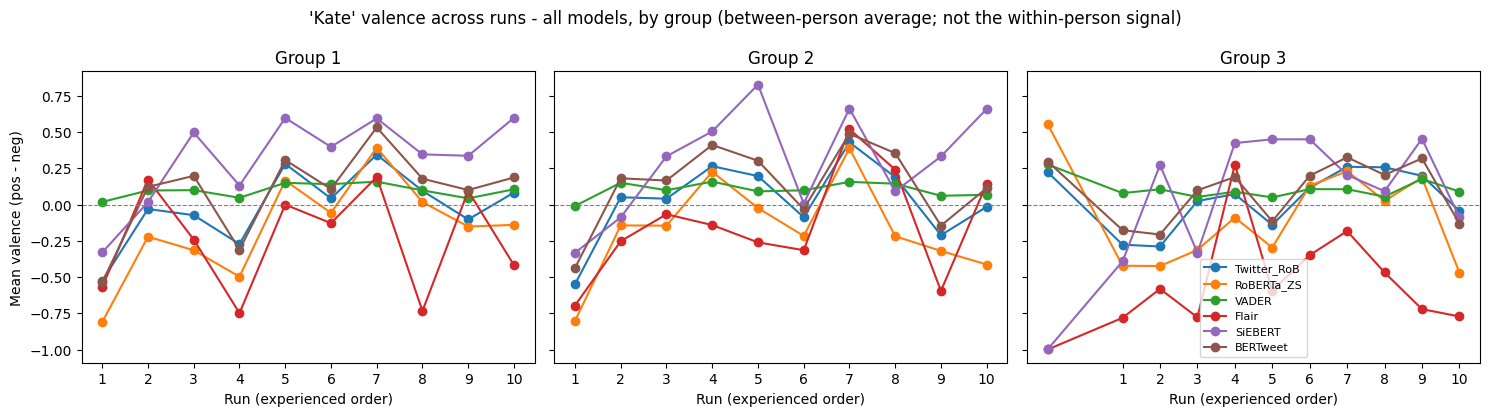

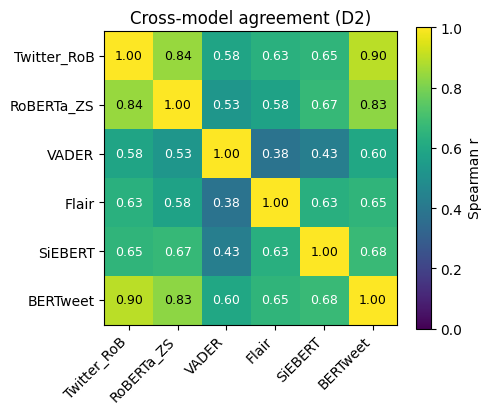

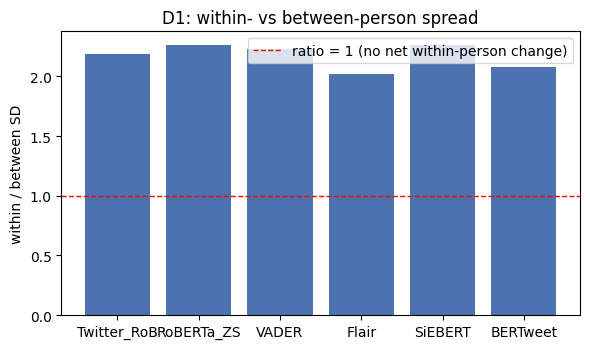

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# group from participant id: sub-1xxx/2xxx/3xxx -> group 1/2/3 (confirmed convention).
# Analysis is WITHIN group, so "run k" is only content-comparable within a group.
def _grp(pid):
    m = [c for c in str(pid) if c.isdigit()]
    return int(m[0]) if m else np.nan

# ---- 1. SENTIMENT TRAJECTORIES: ALL models, one character, FACETED BY GROUP ----
# (emotion-over-time; Hipson & Mohammad 2021, PLOS ONE)
# CAVEAT: this is a BETWEEN-person average at each run. A flat line here does NOT mean
# "no within-person change" (D1 already shows there is) -- opposing within-person moves
# can cancel in the group mean. Faceting by group keeps each run content-comparable.
CHAR_TO_PLOT = "kate"   # change to any of jack/kate/kevin/randall START WITH KATE for example

tv = scored[["Participant","Run","Character"]].copy()
for m in MODELS:
    tv[m] = scored[f"{m}_pos"] - scored[f"{m}_neg"]
tv["group"] = tv["Participant"].map(_grp)
tv = tv[tv.Character == CHAR_TO_PLOT]

groups = sorted(tv["group"].dropna().unique())
fig, axes = plt.subplots(1, len(groups), figsize=(5*len(groups), 4.2), sharey=True)
if len(groups) == 1: axes = [axes]
for ax, g in zip(axes, groups):
    sub = tv[tv.group == g]
    for m in MODELS:
        d = sub.groupby("Run")[m].mean()
        ax.plot(d.index, d.values, marker="o", label=m)
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.set_title(f"Group {int(g)}"); ax.set_xlabel("Run (experienced order)")
    ax.set_xticks(range(1,11))
axes[0].set_ylabel("Mean valence (pos - neg)")
axes[-1].legend(fontsize=8)
fig.suptitle(f"'{CHAR_TO_PLOT.capitalize()}' valence across runs - all models, by group "
             f"(between-person average; not the within-person signal)")
plt.tight_layout(); plt.show()

# ---- 2. MODEL-AGREEMENT HEATMAP: D2 Spearman matrix as an RSA-style heatmap ----
# (Kriegeskorte, Mur & Bandettini 2008)
corr = val[mods].corr("spearman")
fig, ax = plt.subplots(figsize=(5,4.2))
im = ax.imshow(corr.values, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(mods))); ax.set_xticklabels(mods, rotation=45, ha="right")
ax.set_yticks(range(len(mods))); ax.set_yticklabels(mods)
for a in range(len(mods)):
    for b in range(len(mods)):
        ax.text(b, a, f"{corr.values[a,b]:.2f}", ha="center", va="center",
                color="white" if corr.values[a,b]<0.7 else "black", fontsize=9)
fig.colorbar(im, label="Spearman r"); ax.set_title("Cross-model agreement (D2)")
plt.tight_layout(); plt.show()

# ---- 3. WITHIN/BETWEEN RATIO: the D1 result as a bar chart ----
ratio = (within/between)
fig, ax = plt.subplots(figsize=(6,3.6))
ax.bar(ratio.index, ratio.values, color="#4C72B0")
ax.axhline(1, color="red", ls="--", lw=1, label="ratio = 1 (no net within-person change)")
ax.set_ylabel("within / between SD"); ax.set_title("D1: within- vs between-person spread")
ax.legend(); plt.tight_layout(); plt.show()


## 0.5 Build character profiles (per method)
**Primary object = the raw 10-run levels profile** — what the mentors specified ("10 runs per person"; each row = what the participant thinks about the character at that run).

Two **derived** views are saved beside it for the change-focused question:
- `*_centered`: each profile minus its own mean — removes baseline level, keeps the **shape** (still 10 entries).
- `delta_profiles_*`: consecutive-run **changes** (9 per full profile; changes live *between* runs).

Levels stay the base object; centering/deltas are transformations of it, not replacements. The RDM evaluation (next) can run on any of the three — no brain data yet.

In [13]:
# === 0.5 Build CHARACTER PROFILES (per method) ===
# Methods / citations:
#  - Profiles -> RDM evaluation follows RSA: Kriegeskorte, Mur & Bandettini (2008,
#    Front. Syst. Neurosci. 2:4); social/affective RSA guide: Popal, Wang & Olson
#    (2019, SCAN 14(11):1243-1253).
#  - Run-to-run DELTAS / trajectory change on affective scores: Utterance Emotion
#    Dynamics, Hipson & Mohammad (2021, PLOS ONE 16(9):e0256153).
#  - Mean-centering to isolate trajectory SHAPE (remove baseline level) is the standard
#    move before correlation-based RDMs (Walther et al., 2016, NeuroImage 137:188).
#  - Validate-then-test (pick baseline on behavior, NOT on the brain) to avoid
#    double-dipping: Kriegeskorte et al. (2009, Nat. Neurosci. 12:535).
# PRIMARY object = the raw 10-run LEVELS profile (what the mentors specified:
#   "10 runs per person", "every row is what the participant thinks about the character").
# We ALSO produce two derived views for the change-focused research question.
# Levels are primary; centered/deltas are clearly-labeled transformations OF it.
#
# Per method, three files (long form, inspectable):
#   profiles_<m>.csv          PRIMARY  : raw run-resolved levels (up to 10 rows / profile)
#   profiles_<m>_centered.csv DERIVED  : each profile minus its own per-(P,char) mean
#                                        -> removes baseline level, keeps SHAPE (10 rows)
#   delta_profiles_<m>.csv    DERIVED  : consecutive-run changes (9 per full profile)
#
# Order = experienced Run order, within group. Missing runs: centering uses present
# runs; deltas are taken only across ADJACENT present runs (a gap yields no delta).

def build_profiles(score_df, feature_cols, method):
    import os
    os.makedirs("results/profiles", exist_ok=True); os.makedirs("results/deltas", exist_ok=True)
    # ---- PRIMARY: raw levels (10 entries) ----
    levels = (score_df[["Participant","Run","Character"] + feature_cols]
              .dropna(subset=feature_cols, how="all")
              .sort_values(["Participant","Character","Run"]))
    levels.to_csv(f"results/profiles/00__profiles_{method}.csv", index=False)

    # ---- DERIVED 1: mean-centered levels (10 entries, baseline removed -> shape) ----
    centered = levels.copy()
    centered[feature_cols] = (
        centered.groupby(["Participant","Character"])[feature_cols]
                .transform(lambda x: x - x.mean()))
    centered.to_csv(f"results/profiles/00__profiles_{method}_centered.csv", index=False)

    # ---- DERIVED 2: entry-level run-to-run deltas (9 per full profile) ----
    delta_rows = []
    for (p, ch), g in levels.groupby(["Participant","Character"]):
        g = g.sort_values("Run"); runs = g["Run"].tolist()
        X = g[feature_cols].to_numpy(dtype=float)
        for k in range(1, len(runs)):
            row = {"Participant": p, "Character": ch,
                   "Run_from": runs[k-1], "Run_to": runs[k]}
            row.update({f"d_{c}": (X[k]-X[k-1])[j] for j, c in enumerate(feature_cols)})
            delta_rows.append(row)
    deltas = pd.DataFrame(delta_rows)
    deltas.to_csv(f"results/deltas/00__delta_profiles_{method}.csv", index=False)
    return levels, centered, deltas

# classifiers: features = [pos, neg]
for m in MODELS:
    lv, ce, dl = build_profiles(scored, [f"{m}_pos", f"{m}_neg"], m)
    print(f"{m:14s} levels {lv.shape}  centered {ce.shape}  deltas {dl.shape}")


Twitter_RoB    levels (1283, 5)  centered (1283, 5)  deltas (1151, 6)
RoBERTa_ZS     levels (1283, 5)  centered (1283, 5)  deltas (1151, 6)
VADER          levels (1283, 5)  centered (1283, 5)  deltas (1151, 6)
Flair          levels (1283, 5)  centered (1283, 5)  deltas (1151, 6)
SiEBERT        levels (1283, 5)  centered (1283, 5)  deltas (1151, 6)
BERTweet       levels (1283, 5)  centered (1283, 5)  deltas (1151, 6)


## 0.6 (WHAT IS NEXTTTT) In service of
Run-vectors → stack into profiles → validate profiles against group-level behavioral ground truth (next step) → feed validated profiles into the brain/RSA analysis (does across-run sentiment change track neural change?)